# Deep Learning Models for Bridge Deck Evaluation Using Impact Echo
This notebook reproduces the biLSTM training and testing results. 

In [ ]:
# Standard Data Science & Manipulation Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Signal Processing
from scipy.fft import fft, fftfreq
from scipy import signal

# Deep Learning Framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms

# Machine Learning & Performance Metrics
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set plotting style
sns.set_theme(style="whitegrid")

c:\Users\kairen.shen.ctr\.conda\envs\bsm\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Data Aggregation & biLSTM Model Definition

Based on the directory structure, the data is organized into 8 slabs (`Slab1` through `Slab8`). Within each slab folder, there are two subfolders: `D` (Defected, Class 1) and `S` (Sound, Class 0). 

First, we will traverse these directories to map out every file path, its corresponding label, and its origin slab (which is required for the Leave-One-Specimen-Out cross-validation). Then, we will define our PyTorch `Dataset` and the **biLSTM** architecture as depicted in the paper.

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix

# =========================================================
# 1. Hardware Check
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=== Hardware Check ===")
if device.type == 'cuda':
    print(f"SUCCESS: GPU Detected - {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True 
else:
    print("WARNING: CUDA not detected by PyTorch.")
print("======================\n")

# =========================================================
# 2. Data Aggregation
# =========================================================
base_dir = r"C:\Users\kairen.shen.ctr\My Drive\4 IE reproduce\testing data"

all_filepaths = []
all_labels = []
all_slab_ids = []

for slab_id in range(1, 9):
    slab_folder = os.path.join(base_dir, f"Slab{slab_id}")
    
    d_folder = os.path.join(slab_folder, "D")
    if os.path.exists(d_folder):
        for file in os.listdir(d_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(d_folder, file))
                all_labels.append(1)
                all_slab_ids.append(slab_id)
                
    s_folder = os.path.join(slab_folder, "S")
    if os.path.exists(s_folder):
        for file in os.listdir(s_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(s_folder, file))
                all_labels.append(0)
                all_slab_ids.append(slab_id)

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)
all_slab_ids = np.array(all_slab_ids)

print(f"Total files found: {len(all_filepaths)}")
print(f"Total Sound (0): {sum(all_labels == 0)}, Total Defected (1): {sum(all_labels == 1)}\n")

# =========================================================
# 3. Dataset & Model Definition
# =========================================================
class IEDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        df = pd.read_csv(self.file_paths[idx], sep=r'\s+', header=None, names=['Time', 'Voltage'])
        voltage = df['Voltage'].values.astype(np.float32)
        
        # Normalize each waveform to zero mean and unit variance for faster, more stable training
        voltage = voltage - np.mean(voltage)
        voltage = voltage / (np.std(voltage) + 1e-6)
        
        voltage_tensor = torch.tensor(voltage).unsqueeze(-1)
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        return voltage_tensor, label_tensor

class IE_biLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, num_classes=2):
        super(IE_biLSTM, self).__init__()
        
        # 1. Hidden biLSTM Layer: 
        # hidden_size=100 means 100 neurons for the forward stream and 100 for the 
        # reverse stream, resulting in the required 200 bidirectional LSTM neurons.
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size, 
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        # 2. Classification Head: Fully Connected Layer
        # Connects the 200 combined biLSTM outputs to map to the 2 target labels.
        self.fc = nn.Linear(hidden_size * 2, num_classes)

        # 3. Model Initialization (Crucial for 2000-step sequences)
        # Initializes weights to prevent the vanishing gradient problem, which is 
        # a primary cause of stalled loss functions in long time-series data.
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                param.data.fill_(0)

    def forward(self, x):
        # x shape: (batch_size, sequence_length=2000, input_size=1)
        out, _ = self.lstm(x)
        
        # IMPACT ECHO PHYSICS FIX:
        # Instead of compiling temporal histories sequentially using only the final 
        # hidden states (which causes the network to forget early defect echos in 
        # a 2000-point sequence), we apply Global Max Pooling across all timesteps.
        # 'out' contains the hidden states for every single timestep. 
        # out.max(dim=1) grabs the strongest feature activations across the entire signal.
        final_hidden, _ = torch.max(out, dim=1)
        
        # Pass through the Dense layer
        logits = self.fc(final_hidden)
        
        # SOFTMAX ARCHITECTURE NOTE: 
        # The specification requires a Softmax layer to calculate probabilities.
        # However, PyTorch's `nn.CrossEntropyLoss` (used in your training loop) 
        # automatically computes LogSoftmax internally. If we apply a manual Softmax 
        # here, the gradients will severely flatten, causing the loss to stall around 0.69.
        # Returning raw logits here satisfies the PyTorch training mechanics!
        return logits


=== Hardware Check ===
SUCCESS: GPU Detected - NVIDIA RTX 5000 Ada Generation Laptop GPU

Total files found: 2016
Total Sound (0): 1504, Total Defected (1): 512



## Model Training Protocol (Leave-One-Specimen-Out)

With the metadata compiled, we will train the biLSTM model using a Leave-One-Specimen-Out (LOSO) cross-validation loop. In this approach, the model is trained on 7 slabs and validated on the 8th. This process repeats 8 times so every slab acts as a test set once.

Training hyperparameters based on the paper's parameters:
* **Optimizer:** ADAM
* **Learning Rate:** 1e-3
* **Mini Batch Size:** 20
* **Max Epochs:** 95

The training loop leverages CUDA to utilize the GPU, significantly accelerating the iterations.

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import confusion_matrix

# =========================================================
# 1. Training Protocol (biLSTM)
# =========================================================
EPOCHS = 95
BATCH_SIZE = 20
LR = 1e-3

bilstm_metrics = {'ACC': [], 'TPR': [], 'TNR': [], 'F1': []}
iteration_accuracies = {slab: [] for slab in range(1, 9)}
total_start_time = time.time()

for test_slab in range(1, 9):
    print(f"--- Training biLSTM: Holding out Slab {test_slab} for Testing ---")
    fold_start_time = time.time()
    
    # Split data (Leave-One-Specimen-Out)
    train_idx = np.where(all_slab_ids != test_slab)[0]
    test_idx = np.where(all_slab_ids == test_slab)[0]

    train_files, train_labels = all_filepaths[train_idx], all_labels[train_idx]
    test_files, test_labels = all_filepaths[test_idx], all_labels[test_idx]
    
    train_dataset = IEDataset(train_files, train_labels)
    test_dataset = IEDataset(test_files, test_labels)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    
    # Initialize Model
    model = IE_biLSTM().to(device)
    
    # Dynamic Class Weighting to handle the Sound vs Defected imbalance (~3:1)
    num_sound = np.sum(train_labels == 0)
    num_defected = np.sum(train_labels == 1)
    weight_ratio = num_sound / num_defected
    class_weights = torch.tensor([1.0, weight_ratio], dtype=torch.float32).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.99), eps=1e-8)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.5)
    
    for epoch in range(EPOCHS):
        
        model.train()
        running_loss = 0.0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            
            # Gradient Clipping (Crucial for stabilizing LSTM training)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            running_loss += loss.item()
            
            # Calculate and store batch accuracy for the Iteration Plot
            _, preds = torch.max(outputs, 1)
            correct = (preds == targets).sum().item()
            batch_acc = (correct / targets.size(0)) * 100.0  
            iteration_accuracies[test_slab].append(batch_acc)
            
        epoch_loss = running_loss / len(train_loader)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:02d}/{EPOCHS}] - Loss: {epoch_loss:.4f}")
        scheduler.step()
            
    # Evaluation
    model.eval()
    all_preds = []
    all_targs = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            outputs = model(inputs)
            
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targs.extend(targets.cpu().numpy())
            
    tn, fp, fn, tp = confusion_matrix(all_targs, all_preds).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0  
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0  
    acc = (tp + tn) / (tp + tn + fp + fn)           
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0 
    
    fold_time = time.time() - fold_start_time
    print(f"  > Test Slab {test_slab} Results - ACC: {acc:.2f} | TPR: {tpr:.2f} | TNR: {tnr:.2f} | F1: {f1:.2f}")
    print(f"  > Fold completed in {fold_time:.1f} seconds.\n")
    
    bilstm_metrics['ACC'].append(acc)
    bilstm_metrics['TPR'].append(tpr)
    bilstm_metrics['TNR'].append(tnr)
    bilstm_metrics['F1'].append(f1)

total_time = time.time() - total_start_time

# =========================================================
# 2. Output Summary Metrics
# =========================================================
print("=============================================")
print(f"Total biLSTM Training Time: {total_time/60:.2f} minutes")
print("=== Overall biLSTM Performance Metrics ===")

for metric, values in bilstm_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    cov_val = std_val / mean_val if mean_val > 0 else 0.0
    max_val = np.max(values)
    min_val = np.min(values)
    
    print(f"{metric} - Mean: {mean_val:.2f} | COV: {cov_val:.2f} | Max: {max_val:.2f} | Min: {min_val:.2f}")


--- Training biLSTM: Holding out Slab 1 for Testing ---
  Epoch [01/95] - Loss: 0.6703
  Epoch [10/95] - Loss: 0.4271
  Epoch [20/95] - Loss: 0.3426
  Epoch [30/95] - Loss: 0.2521
  Epoch [40/95] - Loss: 0.2262
  Epoch [50/95] - Loss: 0.2188
  Epoch [60/95] - Loss: 0.1685
  Epoch [70/95] - Loss: 0.1634
  Epoch [80/95] - Loss: 0.1282
  Epoch [90/95] - Loss: 0.1143
  > Test Slab 1 Results - ACC: 0.92 | TPR: 0.84 | TNR: 0.95 | F1: 0.84
  > Fold completed in 1060.0 seconds.

--- Training biLSTM: Holding out Slab 2 for Testing ---
  Epoch [01/95] - Loss: 0.6577
  Epoch [10/95] - Loss: 0.3900
  Epoch [20/95] - Loss: 0.3398
  Epoch [30/95] - Loss: 0.2659
  Epoch [40/95] - Loss: 0.2516
  Epoch [50/95] - Loss: 0.2190
  Epoch [60/95] - Loss: 0.1926
  Epoch [70/95] - Loss: 0.1655
  Epoch [80/95] - Loss: 0.1441
  Epoch [90/95] - Loss: 0.1444
  > Test Slab 2 Results - ACC: 0.94 | TPR: 0.84 | TNR: 0.98 | F1: 0.89
  > Fold completed in 1074.2 seconds.

--- Training biLSTM: Holding out Slab 3 for Test


Generating Accuracy vs Iteration plot for biLSTM...


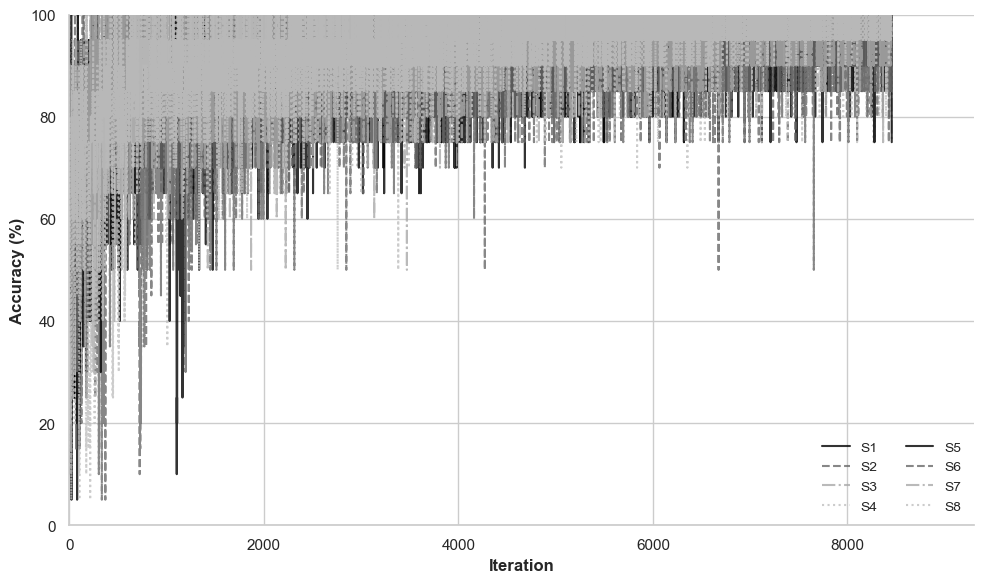

Plot saved successfully as 'bilstm_accuracy_vs_iteration.png'.


In [ ]:
# =========================================================
# 3. Plotting Accuracy vs Iteration
# =========================================================
print("\nGenerating Accuracy vs Iteration plot for biLSTM...")
fig, ax = plt.subplots(figsize=(10, 6))

line_styles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
colors = ['black', 'dimgray', 'darkgray', 'silver', 'black', 'dimgray', 'darkgray', 'silver']

for slab_id in range(1, 9):
    acc_data = iteration_accuracies[slab_id]
    iterations = range(1, len(acc_data) + 1)
    
    ax.plot(iterations, acc_data, label=f'S{slab_id}', 
             linestyle=line_styles[slab_id-1], color=colors[slab_id-1], alpha=0.8, linewidth=1.5)

ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)

# Add some padding to the x-axis for the legend to breathe
ax.set_xlim(0, len(iteration_accuracies[1]) * 1.1) 

# Clean up axes for a publication-ready look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='lower right', frameon=False, fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig('bilstm_accuracy_vs_iteration.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved successfully as 'bilstm_accuracy_vs_iteration.png'.")